# Atividade 23/02/2026: Exploração de Dados Públicos com Estatística Descritiva
Aluno: Vitor Hugo Trovão de Moraes

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Abertura do dataset
df = pd.read_csv('Leitos_2025.csv', sep=';', encoding='latin1')

# 1. Visão Geral do Dataset

- Base de Dados: Hospitais e Leitos, disponível em: https://dados.gov.br/dados/conjuntos-dados/hospitais-e-leitos
- Órgão responsável pela publicação: Ministério da Saúde
- Descrição do tema e finalidade:
Dados gerais dos estabelecimentos hospitalares públicos e privados do Brasil, incluindo os leitos gerais e complementares disponíveis por competência de mês/ano

In [3]:
# Total de Registros e Colunas do Dataset
print(f"Registros = {df.shape[0]}, Colunas = {df.shape[1]}")

Registros = 86147, Colunas = 35


A lista abaixo mostra as colunas existentes na base de dados. Entre as variáveis consideradas importantes para análise destacam-se LEITOS_EXISTENTES e LEITO_SUS como variáveis quantitativas, que serão o foco deste trabalho nas estatísticas descritivas e gráficos. Também será usado a REGIAO e para identificar e agrupar os dados na visualização.

In [4]:
# Listando as variáveis ou colunas do dataset
for i in range(len(df.columns)):
  print(f"{i+1} - {df.columns[i]}")

1 - COMP
2 - REGIAO
3 - UF
4 - CO_IBGE
5 - MUNICIPIO
6 - MOTIVO_DESABILITACAO
7 - CNES
8 - NOME_ESTABELECIMENTO
9 - RAZAO_SOCIAL
10 - TP_GESTAO
11 - CO_TIPO_UNIDADE
12 - DS_TIPO_UNIDADE
13 - NATUREZA_JURIDICA
14 - DESC_NATUREZA_JURIDICA
15 - NO_LOGRADOURO
16 - NU_ENDERECO
17 - NO_COMPLEMENTO
18 - NO_BAIRRO
19 - CO_CEP
20 - NU_TELEFONE
21 - NO_EMAIL
22 - LEITOS_EXISTENTES
23 - LEITOS_SUS
24 - UTI_TOTAL_EXIST
25 - UTI_TOTAL_SUS
26 - UTI_ADULTO_EXIST
27 - UTI_ADULTO_SUS
28 - UTI_PEDIATRICO_EXIST
29 - UTI_PEDIATRICO_SUS
30 - UTI_NEONATAL_EXIST
31 - UTI_NEONATAL_SUS
32 - UTI_QUEIMADO_EXIST
33 - UTI_QUEIMADO_SUS
34 - UTI_CORONARIANA_EXIST
35 - UTI_CORONARIANA_SUS


# 2. Exploração e Análise dos Dados

Calcular estatísticas descritivas:
- Média, mediana, moda
- Mínimo, máximo
- Desvio padrão, variância
- Quartis e intervalo interquartil (IQR)
- Contar valores ausentes e tipos de dados
- Gerar visualizações como histogramas, boxplots e gráficos de dispersão
- Comentar os resultados: que padrões ou irregularidades você observou?

## Tratamento dos Dados

In [5]:
# Resumo do dataset e a existência de valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86147 entries, 0 to 86146
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   COMP                    86147 non-null  int64  
 1   REGIAO                  86147 non-null  object 
 2   UF                      86147 non-null  object 
 3   CO_IBGE                 86147 non-null  int64  
 4   MUNICIPIO               86147 non-null  object 
 5   MOTIVO_DESABILITACAO    0 non-null      float64
 6   CNES                    86147 non-null  int64  
 7   NOME_ESTABELECIMENTO    86147 non-null  object 
 8   RAZAO_SOCIAL            86147 non-null  object 
 9   TP_GESTAO               86147 non-null  object 
 10  CO_TIPO_UNIDADE         86147 non-null  int64  
 11  DS_TIPO_UNIDADE         86147 non-null  object 
 12  NATUREZA_JURIDICA       86147 non-null  int64  
 13  DESC_NATUREZA_JURIDICA  86147 non-null  object 
 14  NO_LOGRADOURO           86147 non-null

In [6]:
# Contagem de Nulos
df.isnull().sum()

,0
COMP,0
REGIAO,0
UF,0
CO_IBGE,0
MUNICIPIO,0
MOTIVO_DESABILITACAO,86147
CNES,0
NOME_ESTABELECIMENTO,0
RAZAO_SOCIAL,0
TP_GESTAO,0


Considerando a tabela anterior sobre as colunas do dataset, identificam-se que as variáveis MOTIVO_DESABILITACAO, NO_COMPLEMENTO, NO_TELEFONE, NO_EMAIL, possuem valores ausentes e não serão usados nessa análise.
Também não entram as variáveis de identificação jurídica, contato e localizações mais específicas além da Região, para manter o escopo regional da análise.

O dataset possui 35 atributos que descrevem os estabelecimentos de saúde quanto a localização, natureza e quantidade de leitos registrados no total e pelo SUS. A tabela indica a presença de dados categóricos à respeito da demografia (REGIAO, UF, CO_IBGE, MUNICIPIO), estabelecimento (CNES, NOME_ESTABELECIMENTO, NATUREZA_JURIDICA, TIPO_UNIDADE, TP_GESTAO), além de dados textuais sobre contato e localização (NO_LOGRADOURO, NU_ENDERECO, NO_COMPLEMENTO, NO_BAIRRO, CO_CEP, NU_TELEFONE, NU_EMAIL). Sobre os leitos são definidos em numéricos discretos, tanto em LEITOS_EXISTENTES quanto LEITOS_SUS e demais naturezas

In [7]:
# Removendo colunas que não serão usadas para análise
rm_columns = ['COMP', 'CO_IBGE', 'UF', 'MUNICIPIO',
              'MOTIVO_DESABILITACAO', 'RAZAO_SOCIAL', 'NATUREZA_JURIDICA',
              'TP_GESTAO', 'NO_LOGRADOURO', 'NU_ENDERECO',
              'NO_COMPLEMENTO', 'NO_BAIRRO', 'CO_CEP', 'NU_TELEFONE',
              'NO_EMAIL', 'CO_TIPO_UNIDADE', 'DS_TIPO_UNIDADE',
              'DESC_NATUREZA_JURIDICA', 'UTI_TOTAL_EXIST', 'UTI_TOTAL_SUS',
              'UTI_ADULTO_EXIST', 'UTI_ADULTO_SUS', 'UTI_PEDIATRICO_EXIST',
              'UTI_PEDIATRICO_SUS', 'UTI_NEONATAL_EXIST', 'UTI_NEONATAL_SUS',
              'UTI_QUEIMADO_EXIST', 'UTI_QUEIMADO_SUS', 'UTI_CORONARIANA_EXIST',
              'UTI_CORONARIANA_SUS']


In [8]:
df_novo = df.copy()
df_novo.drop(columns=rm_columns, inplace=True)

In [9]:
# Transformar variáveis categóricas em strings (objects)
codigo_columns = ['CNES']
df_novo[codigo_columns] = df_novo[codigo_columns].astype('str')
df_novo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86147 entries, 0 to 86146
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   REGIAO                86147 non-null  object
 1   CNES                  86147 non-null  object
 2   NOME_ESTABELECIMENTO  86147 non-null  object
 3   LEITOS_EXISTENTES     86147 non-null  int64 
 4   LEITOS_SUS            86147 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 3.3+ MB


In [10]:
df_novo.head(5)

,REGIAO,CNES,NOME_ESTABELECIMENTO,LEITOS_EXISTENTES,LEITOS_SUS
0,NORDESTE,27,CASA DE SAUDE SANTA HELENA,64,0
1,NORDESTE,35,HOSPITAL MENDO SAMPAIO,19,19
2,NORDESTE,94,MATERNIDADE PADRE GERALDO LEITE BASTOS,18,18
3,NORDESTE,183,HOSPITAL SAMARITANO,59,0
4,NORDESTE,221,HOSPITAL SAO SEBASTIAO,52,0


In [11]:
# Contagem de duplicadas
df_novo.duplicated().value_counts()

,count
True,76038
False,10109


In [12]:
# Mantendo apenas os registros únicos por estabelecimento
# a partir do código identificador CNES
df_drop = df_novo.drop_duplicates(subset='CNES').reset_index(drop=True)

## Estatística Descritiva

In [14]:
# Colunas para estatística descritiva
columns = ['LEITOS_EXISTENTES', 'LEITOS_SUS']

# Estatística Descritiva
columns_map = {
    "Leitos Existentes": "LEITOS_EXISTENTES",
    "Leitos SUS": "LEITOS_SUS",
}

summary_data = {}

# Cálculo por cada coluna
for name, col in columns_map.items():
    series = df_drop[col]
    media = series.mean()
    mediana = series.median()
    moda = series.mode()[0]
    minimo = series.min()
    maximo = series.max()
    desvio_padrao = series.std()
    variancia = series.var()
    summary_data[name] = [media, mediana, moda, minimo, maximo, desvio_padrao, variancia]

# Armazenando resultado
summary_df = pd.DataFrame(
    summary_data,
    index=["Média", "Mediana", "Moda", "Minimo", "Maximo", "Desvio Padrão", "Variância"]
    ).T.round(2)
summary_df

,Média,Mediana,Moda,Minimo,Maximo,Desvio Padrão,Variância
Leitos Existentes,70.88,40.0,50.0,1.0,1543.0,93.76,8791.48
Leitos SUS,47.74,23.0,0.0,0.0,1476.0,81.15,6585.79


In [15]:
#Intervalo Interquartil
iqr_data = {}
for name, col in columns_map.items():
  series = df_drop[col]
  q1 = series.quantile(0.25)
  q2 = series.median()
  q3 = series.quantile(0.75)
  max = series.max()
  min = series.min()
  iqr = q3 - q1
  iqr_data[name] = [min, q1, q2, q3, max, iqr]

IQR_df = pd.DataFrame(
    iqr_data,
    index=["min", "25%", "50%", "75%", "max", "IQR"]
    ).T.round(2)
IQR_df

,min,25%,50%,75%,max,IQR
Leitos Existentes,1.0,19.0,40.0,86.0,1543.0,67.0
Leitos SUS,0.0,1.0,23.0,55.0,1476.0,54.0


# 3. Visualizações

## Distribuição de Leitos Existentes (Total e SUS)

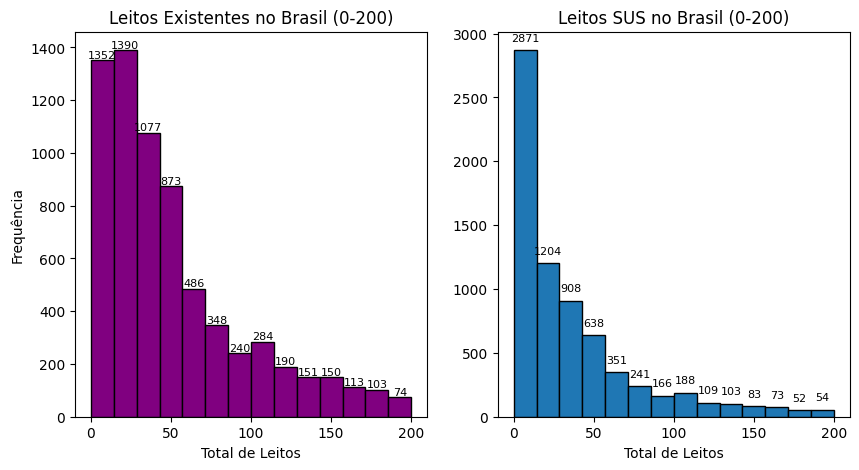

In [16]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(df_drop['LEITOS_EXISTENTES'], bins=14, color='purple',
         range=(0, 200), edgecolor='black')
plt.title('Leitos Existentes no Brasil (0-200)')
plt.bar_label(plt.gca().containers[0], fontsize=8)
plt.xlabel("Total de Leitos")
plt.ylabel("Frequência")

plt.subplot(1, 2, 2)
plt.hist(df_drop['LEITOS_SUS'], bins=14,
            range=(0, 200), edgecolor='black')
plt.title('Leitos SUS no Brasil (0-200)')
plt.bar_label(plt.gca().containers[0], padding=5, fontsize=8)
plt.xlabel("Total de Leitos")

plt.show()

Os gráficos acima indicam uma assimetria à direita para os dois grupos de leitos. Essa assimetria é mais acentuada no segundo gráfico. Assim, podemos dizer que há uma concentração de estabelecimentos com até 50 leitos, e diminui essa quantidade conforme o total de leitos

## Total de Leitos por Região

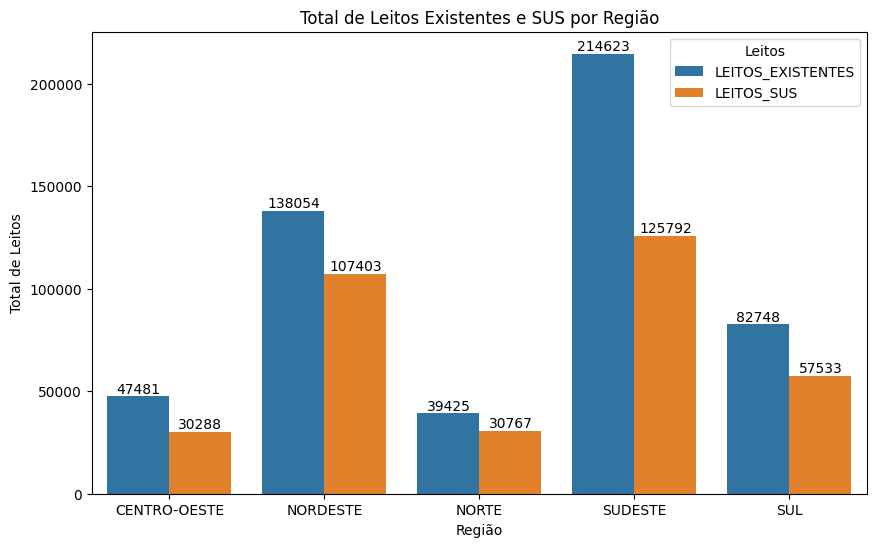

In [17]:
# Agrupando os dados por região
df_regiao = df_drop.groupby('REGIAO')[
    ['LEITOS_EXISTENTES', 'LEITOS_SUS']
].sum().reset_index()

# Transformar o dataset agrupando o total de leitos por tipo (Existente e SUS)
df_melt = df_regiao.melt(
    id_vars='REGIAO',
    value_vars=['LEITOS_EXISTENTES', 'LEITOS_SUS'],
    var_name='Leitos',
    value_name='Total'
)

# Plotando o gráfico
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_melt,
    x='REGIAO',
    y='Total',
    hue='Leitos',
)

for i in range(len(ax.containers)):
  ax.bar_label(ax.containers[i], fontsize=10)

plt.title("Total de Leitos Existentes e SUS por Região")
plt.xlabel("Região")
plt.ylabel("Total de Leitos")

plt.show()


Conforme o gráfico acima, a quantidade de leitos é maior nas regiões Sudeste, Nordeste e Sul. Assim podemos perceber uma desigualdade regional existente, por exemplo entre o Norte e o Sudeste a diferença de leitos é de cerca de 175 mil.

O gráfico também compara os leitos ofertados ao SUS, em que as regiões Sudeste, Nordeste e Sul possuem maior diferença, indicando maior presença de leitos fora do sistema público. Já nas regiões Norte e Centro-Oeste essa diferença é menor, sugerindo que os estabelecimentos possuem maior integração com o SUS.

## Distribuição de Leitos por Região

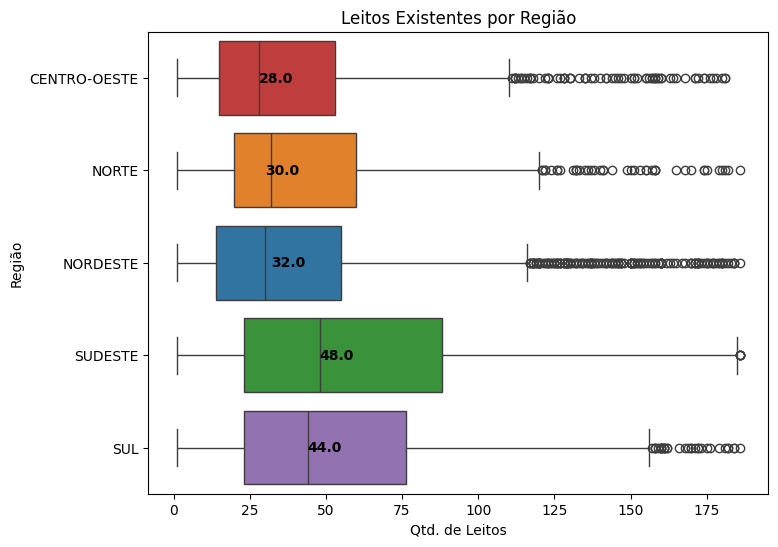

In [18]:
# Definição das Regiões e os Quartis do Dataset
regioes = ['CENTRO-OESTE', 'NORTE', 'NORDESTE', 'SUDESTE', 'SUL']
Q1 = df_drop['LEITOS_EXISTENTES'].quantile(0.25)
Q3 = df_drop['LEITOS_EXISTENTES'].quantile(0.75)
IQR = Q3 - Q1

# Limites Superior e Inferior
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

# Filtrando os dados para melhorar a visualização no gráfico
df_limpo = df_drop[
    ~((df_drop['LEITOS_EXISTENTES'] < (LI))
    | (df_drop['LEITOS_EXISTENTES'] > (LS)))
]

# Obtendo as medianas de cada região para visualizar no gráfico
medianas = df_limpo.groupby('REGIAO')['LEITOS_EXISTENTES'].median()


# Plotando o gráfico
plt.figure(figsize=(8,6))
ax = sns.boxplot(
    data=df_limpo,
    x='LEITOS_EXISTENTES',
    y='REGIAO',
    hue='REGIAO',
    order=regioes
)

# Adicionando as medianas
for i, regiao in enumerate(medianas.index):
    ax.text(
        medianas[regiao],
        i,
        f'{medianas[regiao]:.1f}',
        va='center',
        fontweight='bold',
        color='black'
    )

plt.title("Leitos Existentes por Região")
plt.suptitle("")  # remove título redundante
plt.xlabel("Qtd. de Leitos")
plt.ylabel("Região")
plt.show()

O gráfico acima mostra a distribuição dos leitos por região. Podemos perceber a predominância dos dados na faixa de 20 a 80 leitos em cada região. Também se observam muitos outliers nas regiões Norte, Nordeste, Centro-Oeste e Sul, que ultrapassam a média de leitos, representando os estabelecimentos de grande porte existentes em suas regiões.

## Relação entre os Leitos Totais e Leitos SUS

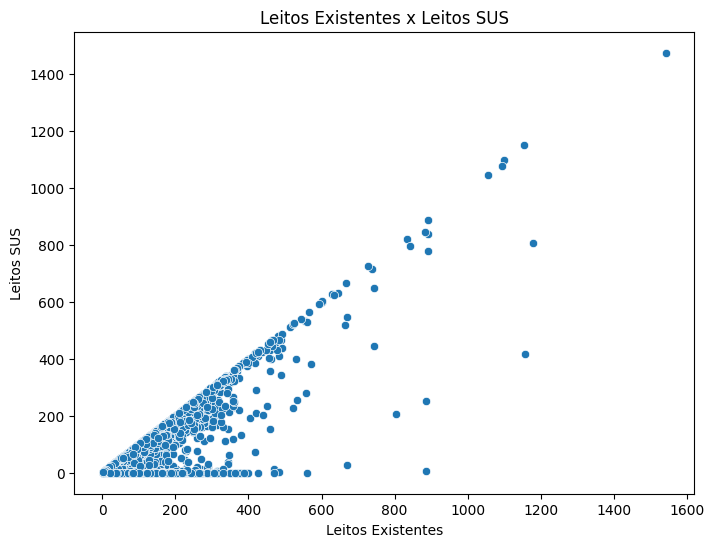

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_drop, x='LEITOS_EXISTENTES', y='LEITOS_SUS')
plt.title("Leitos Existentes x Leitos SUS")
plt.xlabel("Leitos Existentes")
plt.ylabel("Leitos SUS")
plt.show()

# 4. Conclusões

A análise gerou evidências de que a rede hospitalar do Brasil é composta em sua maioria por estabelecimentos de pequeno porte, com uma certa concentração da maioria dos leitos em hospitais de médio a grande porte.

Observou-se também a desigualdade regional na distribuição de leitos, com maior concentração nas regiões Sudeste, Nordeste e Sul.

A relação entre leitos totais e leitos SUS sugere que hospitais maiores tem mais relevância na oferta ao sistema público, e ainda assim, existe uma variação na proporção desses leitos entre os estabelecimentos.



